Loaded studentInfo:       32,593 rows
Loaded studentAssessment: 173,912 rows

C1: Encoding categorical features...

  Sample encodings (first 5 rows):
    highest_education  highest_education_enc imd_band  imd_band_enc gender  gender_enc disability  disability_enc
     HE Qualification                      3  90-100%           9.0      M           1          N               0
     HE Qualification                      3   20-30%           2.0      F           0          N               0
A Level or Equivalent                      2   30-40%           3.0      F           0          Y               1
A Level or Equivalent                      2   50-60%           5.0      F           0          N               0
   Lower Than A Level                      1   50-60%           5.0      F           0          N               0

C2: Building correlation heatmap...
  Correlation matrix computed on 31,482 rows (1,111 dropped due to missing imd_band)



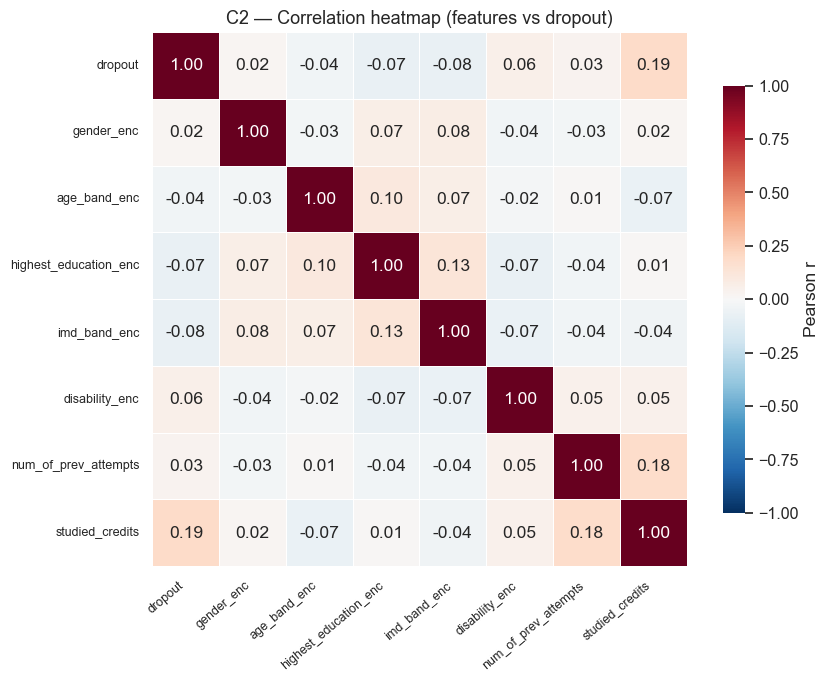

  Saved → ./outputs/block_c/C2_correlation_heatmap.png

  Correlations with 'dropout' (sorted by absolute value):
    studied_credits                |r| = 0.193  (strong, positive)
    imd_band_enc                   |r| = 0.076  (moderate, negative)
    highest_education_enc          |r| = 0.074  (moderate, negative)
    disability_enc                 |r| = 0.057  (moderate, positive)
    age_band_enc                   |r| = 0.037  (weak, negative)
    num_of_prev_attempts           |r| = 0.031  (weak, positive)
    gender_enc                     |r| = 0.017  (weak, positive)

C3: Assessment score vs dropout status...
  Students with assessment scores:    26,727
  Students without assessment scores: 5,866


C:\Users\leade\AppData\Local\Temp\ipykernel_29488\3129353461.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


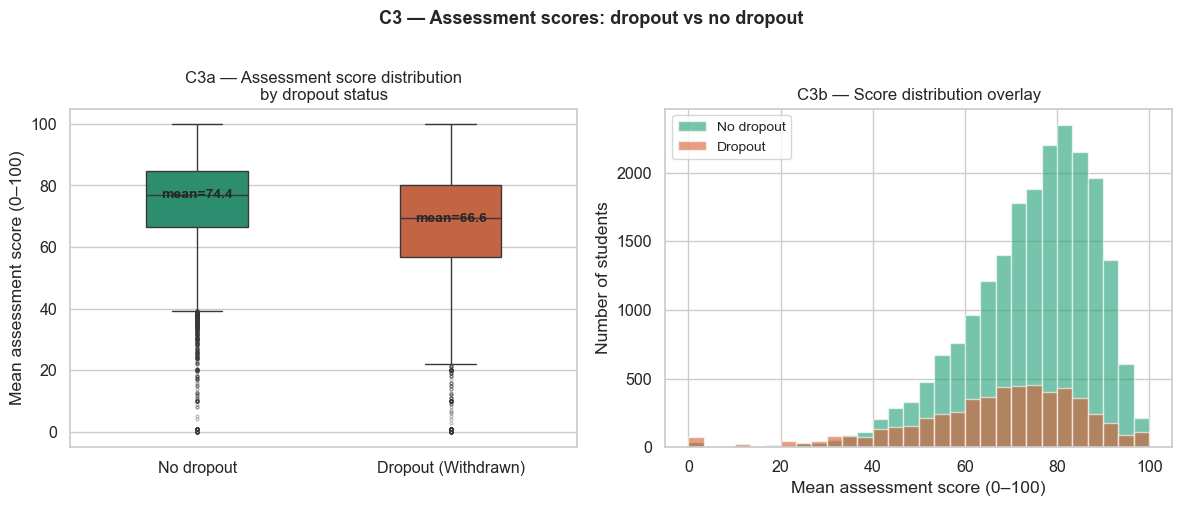

  Saved → ./outputs/block_c/C3_score_vs_dropout.png

  T-test results:
    Mean score — No dropout : 74.45
    Mean score — Dropout    : 66.56
    Difference              : 7.89 points
    t-statistic             : 28.869
    p-value                 : 1.98e-173
    ✅ Statistically significant (p < 0.05)
       Dropout students score meaningfully lower on average.

C4: Feature importance (correlation magnitudes)...


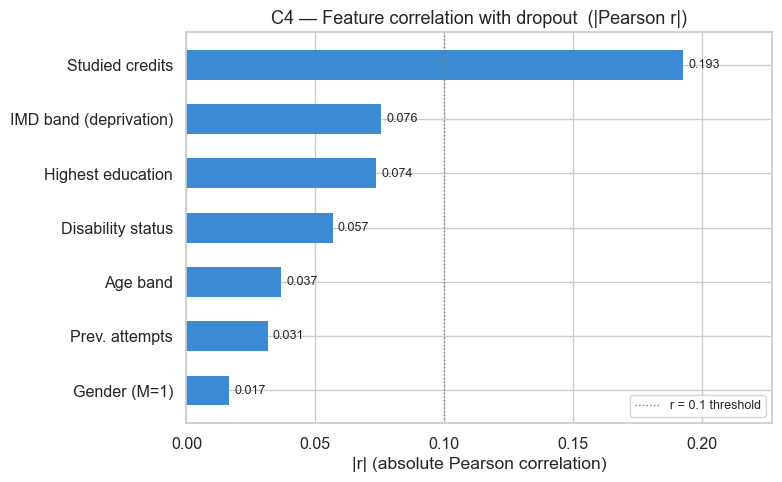

  Saved → ./outputs/block_c/C4_feature_importance_correlation.png

BLOCK C COMPLETE — Correlation Findings

  Strongest predictor of dropout: studied_credits  (|r| = 0.193)

  Assessment score gap:
    No dropout mean : 74.4
    Dropout mean    : 66.6
    Difference      : 7.9 points (p = 1.98e-173)

  Charts saved to: ./outputs/block_c/
    C2_correlation_heatmap.png
    C3_score_vs_dropout.png
    C4_feature_importance_correlation.png

─────────────────────────────────────────────────
Next → Run block_d_timing.py
─────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 2 — Block C: Correlation Analysis
=============================================================
Goal: Quantify which features are most strongly associated with
      dropout. We encode categorical features numerically, build
      a correlation heatmap, and compare assessment scores between
      dropout and non-dropout students.

Key concept — Pearson correlation (r):
  r =  1.0  : perfect positive relationship
  r = -1.0  : perfect negative relationship
  r =  0.0  : no linear relationship
  In social science data, |r| > 0.1 is noteworthy.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats    # for the t-test in C3

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/block_c/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')

si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

print(f"Loaded studentInfo:       {si.shape[0]:,} rows")
print(f"Loaded studentAssessment: {sa.shape[0]:,} rows\n")


# =============================================================
# C1: Encode categorical features as numbers
# =============================================================
# Pearson correlation only works on numeric data.
# We convert categorical columns to numbers using two strategies:
#
#   Ordinal encoding  → for ordered categories (e.g. education level).
#                       We assign integer ranks that respect the natural order.
#
#   Binary encoding   → for two-category columns (e.g. gender, disability).
#                       We map one category to 1 and the other to 0.

print("C1: Encoding categorical features...")

# Work on a copy so we don't modify the original DataFrame
si_enc = si.copy()

# ── Ordinal: highest education (lowest → highest qualification) ──
edu_map = {
    'No Formal quals':             0,
    'Lower Than A Level':          1,
    'A Level or Equivalent':       2,
    'HE Qualification':            3,
    'Post Graduate Qualification': 4
}
si_enc['highest_education_enc'] = si_enc['highest_education'].map(edu_map)

# ── Ordinal: IMD band (most deprived = 0, least deprived = 9) ──
# We reverse the IMD so that higher numbers = less deprived = more advantaged.
# This means a NEGATIVE correlation with dropout makes intuitive sense:
# more advantaged → lower dropout.
imd_map = {
    '0-10%':  0, '10-20':  1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
si_enc['imd_band_enc'] = si_enc['imd_band'].map(imd_map)

# ── Ordinal: age band (youngest = 0, oldest = 2) ──
age_map = {'0-35': 0, '35-55': 1, '55<=': 2}
si_enc['age_band_enc'] = si_enc['age_band'].map(age_map)

# ── Binary: gender (Male = 1, Female = 0) ──
si_enc['gender_enc'] = (si_enc['gender'] == 'M').astype(int)

# ── Binary: disability (Yes = 1, No = 0) ──
si_enc['disability_enc'] = (si_enc['disability'] == 'Y').astype(int)

# Print a sample of the encoded columns
encoded_cols = [
    'highest_education', 'highest_education_enc',
    'imd_band',          'imd_band_enc',
    'gender',            'gender_enc',
    'disability',        'disability_enc',
]
print("\n  Sample encodings (first 5 rows):")
print(si_enc[encoded_cols].head().to_string(index=False))
print()


# =============================================================
# C2: Correlation heatmap
# =============================================================
# We pick all the numeric and newly encoded features, compute
# pairwise Pearson correlations, and show them as a colour heatmap.
#
# Reading the heatmap:
#   - Focus on the 'dropout' row/column
#   - Red = positively correlated with dropout
#   - Blue = negatively correlated with dropout
#   - Numbers close to 0 = weak/no linear relationship

print("C2: Building correlation heatmap...")

# Select features to include in the correlation matrix
corr_cols = [
    'dropout',                  # our target variable
    'gender_enc',               # binary: M=1, F=0
    'age_band_enc',             # ordinal: 0-35=0, 35-55=1, 55<=2
    'highest_education_enc',    # ordinal: 0 (none) → 4 (postgrad)
    'imd_band_enc',             # ordinal: 0 (most deprived) → 9 (least)
    'disability_enc',           # binary: Y=1, N=0
    'num_of_prev_attempts',     # numeric: integer count
    'studied_credits',          # numeric: credit load
]

# dropna() drops rows where ANY of the selected columns is NaN.
# This mainly removes rows with missing imd_band (~5% of data).
corr_df     = si_enc[corr_cols].dropna()
corr_matrix = corr_df.corr(method='pearson')

print(f"  Correlation matrix computed on {len(corr_df):,} rows "
      f"({len(si) - len(corr_df):,} dropped due to missing imd_band)\n")

# ── Plot heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Use a diverging colourmap centred at 0:
# RdBu_r → red (positive), white (zero), blue (negative)
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,           # show the r value inside each cell
    fmt='.2f',            # 2 decimal places
    cmap='RdBu_r',
    center=0,             # white = 0 (no correlation)
    vmin=-1, vmax=1,
    square=True,          # force square cells for readability
    linewidths=0.5,       # thin grid lines between cells
    linecolor='white',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)

ax.set_title("C2 — Correlation heatmap (features vs dropout)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C2_correlation_heatmap.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")

# ── Print correlations with dropout, ranked by strength ───────
print("  Correlations with 'dropout' (sorted by absolute value):")
dropout_corr = (
    corr_matrix['dropout']
    .drop('dropout')           # don't show dropout vs itself
    .abs()
    .sort_values(ascending=False)
)
for feature, r in dropout_corr.items():
    direction = "positive" if corr_matrix.loc[feature, 'dropout'] > 0 else "negative"
    strength  = "strong" if r > 0.15 else "moderate" if r > 0.05 else "weak"
    print(f"    {feature:<30} |r| = {r:.3f}  ({strength}, {direction})")
print()


# =============================================================
# C3: Assessment scores — dropout vs non-dropout
# =============================================================
# Beyond demographics, early assessment performance is one of the most
# powerful dropout signals. If students who will eventually withdraw
# already score lower in early assessments, we can flag them early.
#
# Steps:
#   1. Calculate each student's MEAN score across all assessments
#   2. Merge that mean score back into studentInfo
#   3. Compare means between dropout (1) and non-dropout (0) groups
#   4. Run a t-test to confirm the difference is statistically significant

print("C3: Assessment score vs dropout status...")

# Step 1: mean score per student
# studentAssessment has one row per student per assessment.
# We group by id_student and take the mean score.
mean_scores = (
    sa.groupby('id_student')['score']
      .mean()
      .reset_index()
      .rename(columns={'score': 'mean_score'})
)

# Step 2: merge into studentInfo
# Left join: all students in si are kept. Students with no assessments get NaN.
si_scored = si.merge(mean_scores, on='id_student', how='left')

n_with_scores    = si_scored['mean_score'].notna().sum()
n_without_scores = si_scored['mean_score'].isna().sum()
print(f"  Students with assessment scores:    {n_with_scores:,}")
print(f"  Students without assessment scores: {n_without_scores:,}")

# Step 3: box plot comparing the two groups
si_scored['Dropout status'] = si_scored['dropout'].map(
    {0: 'No dropout', 1: 'Dropout (Withdrawn)'}
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left plot: box plot ───────────────────────────────────────
# The box shows the interquartile range (25th–75th percentile).
# The line inside the box is the median.
# Whiskers extend to 1.5× the IQR. Dots beyond whiskers are outliers.
sns.boxplot(
    data=si_scored.dropna(subset=['mean_score']),
    x='Dropout status',
    y='mean_score',
    palette={'No dropout': COLORS['teal'], 'Dropout (Withdrawn)': COLORS['coral']},
    ax=axes[0],
    width=0.4,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Annotate with the group means
for i, group in enumerate(['No dropout', 'Dropout (Withdrawn)']):
    mean_val = si_scored[si_scored['Dropout status'] == group]['mean_score'].mean()
    axes[0].text(i, mean_val + 1.5, f"mean={mean_val:.1f}",
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("C3a — Assessment score distribution\nby dropout status", fontsize=12)
axes[0].set_ylabel("Mean assessment score (0–100)")
axes[0].set_xlabel("")

# ── Right plot: score distribution histogram overlay ──────────
# Overlaid histograms show the full distribution for both groups.
dropout_scores    = si_scored[si_scored['dropout'] == 1]['mean_score'].dropna()
no_dropout_scores = si_scored[si_scored['dropout'] == 0]['mean_score'].dropna()

axes[1].hist(no_dropout_scores, bins=30, alpha=0.6,
             color=COLORS['teal'], label='No dropout', edgecolor='white')
axes[1].hist(dropout_scores, bins=30, alpha=0.6,
             color=COLORS['coral'], label='Dropout', edgecolor='white')

axes[1].set_title("C3b — Score distribution overlay", fontsize=12)
axes[1].set_xlabel("Mean assessment score (0–100)")
axes[1].set_ylabel("Number of students")
axes[1].legend(fontsize=10)

plt.suptitle("C3 — Assessment scores: dropout vs no dropout",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C3_score_vs_dropout.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")

# Step 4: two-sample t-test
# H0 (null hypothesis): the mean scores of the two groups are equal.
# If p < 0.05 we reject H0 and conclude the difference is statistically significant.
t_stat, p_val = stats.ttest_ind(
    no_dropout_scores,
    dropout_scores,
    equal_var=False   # Welch's t-test — safer when group sizes differ
)

mean_no_dropout = no_dropout_scores.mean()
mean_dropout    = dropout_scores.mean()

print("  T-test results:")
print(f"    Mean score — No dropout : {mean_no_dropout:.2f}")
print(f"    Mean score — Dropout    : {mean_dropout:.2f}")
print(f"    Difference              : {mean_no_dropout - mean_dropout:.2f} points")
print(f"    t-statistic             : {t_stat:.3f}")
print(f"    p-value                 : {p_val:.2e}")
if p_val < 0.05:
    print("    ✅ Statistically significant (p < 0.05)")
    print("       Dropout students score meaningfully lower on average.")
else:
    print("    ⚠ Not statistically significant (p ≥ 0.05)")
print()


# =============================================================
# C4: Feature importance bar chart (correlation magnitudes)
# =============================================================
# A clean horizontal bar chart of |r| values gives a quick visual
# ranking of which features are most linearly related to dropout.
# This is NOT a model — it's just bivariate correlation.

print("C4: Feature importance (correlation magnitudes)...")

# Use the dropout correlations computed in C2
importance = corr_matrix['dropout'].drop('dropout').abs().sort_values()

# Friendly label mapping for the y-axis
label_map = {
    'gender_enc':             'Gender (M=1)',
    'age_band_enc':           'Age band',
    'highest_education_enc':  'Highest education',
    'imd_band_enc':           'IMD band (deprivation)',
    'disability_enc':         'Disability status',
    'num_of_prev_attempts':   'Prev. attempts',
    'studied_credits':        'Studied credits',
}
importance.index = [label_map.get(i, i) for i in importance.index]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importance.index, importance.values,
               color=COLORS['blue'], edgecolor='none', height=0.55)

# Add value labels at the end of each bar
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_title("C4 — Feature correlation with dropout  (|Pearson r|)", fontsize=13)
ax.set_xlabel("|r| (absolute Pearson correlation)")
ax.set_xlim(0, importance.max() * 1.18)

# Reference line at r = 0.1 (conventional "small effect" threshold)
ax.axvline(0.1, color='gray', linestyle=':', linewidth=1, label='r = 0.1 threshold')
ax.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C4_feature_importance_correlation.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK C SUMMARY
# =============================================================
print("=" * 55)
print("BLOCK C COMPLETE — Correlation Findings")
print("=" * 55)

top_feature = corr_matrix['dropout'].drop('dropout').abs().idxmax()
top_r       = corr_matrix['dropout'].drop('dropout').abs().max()

print(f"""
  Strongest predictor of dropout: {top_feature}  (|r| = {top_r:.3f})

  Assessment score gap:
    No dropout mean : {mean_no_dropout:.1f}
    Dropout mean    : {mean_dropout:.1f}
    Difference      : {mean_no_dropout - mean_dropout:.1f} points (p = {p_val:.2e})

  Charts saved to: {OUTPUT_PATH}
    C2_correlation_heatmap.png
    C3_score_vs_dropout.png
    C4_feature_importance_correlation.png

─────────────────────────────────────────────────
Next → Run block_d_timing.py
─────────────────────────────────────────────────
""")